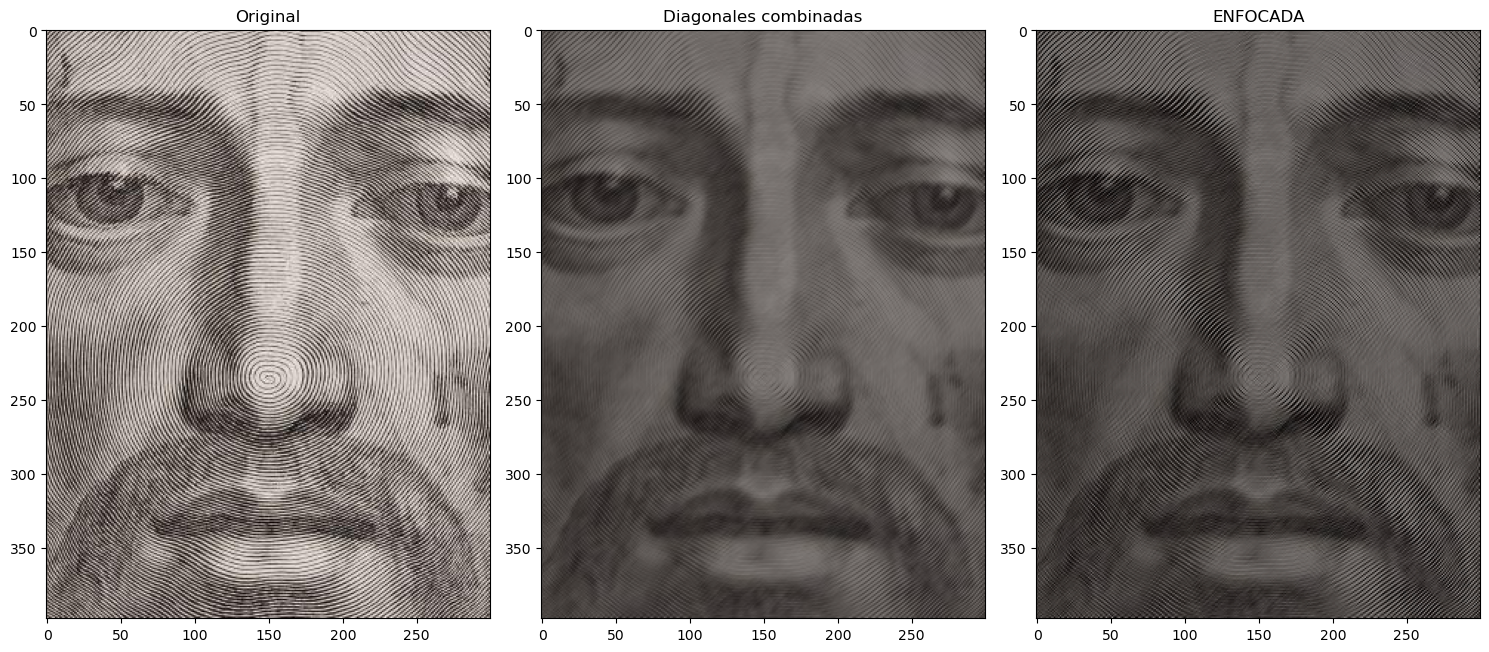

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta_imagen = 'yis.jpeg'

img = cv2.imread(ruta_imagen)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

k = 5

kernel_diag1 = np.eye(k, dtype=np.float32)
kernel_diag2 = np.fliplr(np.eye(k, dtype=np.float32))

kernel_diag1 /= kernel_diag1.sum()
kernel_diag2 /= kernel_diag2.sum()

diag1 = cv2.filter2D(img, -1, kernel_diag1)
diag2 = cv2.filter2D(img, -1, kernel_diag2)

dir_comb = cv2.addWeighted(diag1, 0.2, diag2, 0.4, 0)

dir_float = dir_comb.astype(np.float32)

kernel_sharp = np.array([[0,-1,0],
                         [-1,5,-1],
                         [0,-1,0]], dtype=np.float32)

sharp = cv2.filter2D(dir_float, -1, kernel_sharp)


final = cv2.addWeighted(dir_float, 0.6, sharp, 0.3, 0)

final = np.clip(final, 0, 255)
final = final.astype(np.uint8)

plt.figure(figsize=(15,10))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Original')

plt.subplot(1,3,2)
plt.imshow(dir_comb)
plt.title('Diagonales combinadas')

plt.subplot(1,3,3)
plt.imshow(final)
plt.title('ENFOCADA')

plt.tight_layout()
plt.show()